## filtering

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import timeit
import functools
import tqdm
import random
import string

# GPU Libraries
import cudf
import cupy as cp

In [6]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import timeit
import functools
import tqdm
import random
import string

# GPU Libraries
import cudf
import cupy as cp

# Optional: RMM for memory management
# import rmm
# rmm.reinitialize(pool_allocator=True)

print(f"Using cuDF {cudf.__version__}")
print(f"Using CuPy {cp.__version__}")

# --- Helper Function for String Generation (CPU) ---
def generate_random_strings(num_rows, length=10):
    """Generates a list of random strings on the CPU."""
    return [''.join(random.choices(string.ascii_letters + string.digits, k=length))
            for _ in range(num_rows)]

# --- Modified Function with Type Counts ---
def time_cudf_filter_operation_mixed_types_random_filter(num_rows, num_cols, nan_ratio, target_selectivity):
    """Generates mixed-type cuDF DataFrame, counts types, filters, and times."""
    data_dict = {}
    df = None
    col_names = [f"col_{i}" for i in range(num_cols)]
    filter_col_name = col_names[0]

    # *** Initialize type counters ***
    num_int_cols = 0
    num_float_cols = 0
    num_string_cols = 0

    try:
        # --- 1. Generate Data Column by Column ---

        # Decide type for the filtering column (col_0)
        filter_col_type = random.choice(['int', 'float'])
        filter_cupy_dtype = None

        if filter_col_type == 'int':
            filter_cupy_dtype = cp.int64
            gpu_data = cp.random.randint(0, 1001, size=num_rows, dtype=filter_cupy_dtype)
            data_dict[filter_col_name] = cudf.Series(gpu_data)
            num_int_cols += 1 # *** Increment int counter ***
        else: # 'float'
            filter_cupy_dtype = cp.float64
            gpu_data = cp.random.uniform(0.0, 1000.0, size=num_rows).astype(filter_cupy_dtype)
            data_dict[filter_col_name] = cudf.Series(gpu_data)
            num_float_cols += 1 # *** Increment float counter ***
        # del gpu_data # Optional cleanup

        # Generate remaining columns with mixed types
        column_types = ['int', 'float', 'string']
        cupy_float_dtype = cp.float64
        cupy_int_dtype = cp.int64

        for i in range(1, num_cols):
            col_name = col_names[i]
            chosen_type = random.choice(column_types)

            if chosen_type == 'int':
                data_dict[col_name] = cudf.Series(cp.random.randint(0, 1000, size=num_rows, dtype=cupy_int_dtype))
                num_int_cols += 1 # *** Increment int counter ***
            elif chosen_type == 'float':
                data_dict[col_name] = cudf.Series(cp.random.normal(50.0, 15.0, size=num_rows).astype(cupy_float_dtype))
                num_float_cols += 1 # *** Increment float counter ***
            elif chosen_type == 'string':
                cpu_strings = generate_random_strings(num_rows, length=random.randint(5, 15))
                data_dict[col_name] = cudf.Series(cpu_strings)
                num_string_cols += 1 # *** Increment string counter ***
            else:
                 print(f"Warning: Unexpected type chosen: {chosen_type}")
                 # Assign a default type and count it if needed, e.g., int
                 data_dict[col_name] = cudf.Series(cp.zeros(num_rows, dtype=cp.int32))
                 num_int_cols += 1 # Count as int, for example

        # --- Sanity Check (Optional) ---
        # if num_int_cols + num_float_cols + num_string_cols != num_cols:
        #     print(f"Warning: Column count mismatch! Total counted: {num_int_cols + num_float_cols + num_string_cols}, Expected: {num_cols}")

        # --- 2. Create cuDF DataFrame ---
        df = cudf.DataFrame(data_dict)

        # --- 3. Introduce NaNs/Nulls ---
        actual_nan_ratio = 0.0
        if nan_ratio > 0:
            nan_mask_gpu = cp.random.rand(num_rows) < nan_ratio
            df[filter_col_name] = df[filter_col_name].mask(cudf.Series(nan_mask_gpu), cudf.NA)
            actual_nan_ratio = nan_ratio
            del nan_mask_gpu

        # --- 4. Determine threshold ---
        col_0_valid = df[filter_col_name].dropna()
        if len(col_0_valid) == 0:
             print(f"Warning: Column '{filter_col_name}' has no valid values. Skipping.")
             del col_0_valid
             return None
        threshold = col_0_valid.astype(cp.float64).quantile(target_selectivity, interpolation='linear')
        del col_0_valid
        if threshold is None or threshold is cudf.NA or np.isnan(threshold):
             print(f"Warning: Threshold calculation resulted in NA/NaN. Skipping.")
             return None

        # --- 5. Setup filtering function ---
        filter_func = functools.partial(lambda d, col, t: d[d[col] < t], df, filter_col_name, threshold)

        # --- 6. Time the operation ---
        cp.cuda.runtime.deviceSynchronize()
        _ = filter_func() # Warm-up
        cp.cuda.runtime.deviceSynchronize()
        n_runs = 3
        exec_time_total = timeit.timeit(lambda: (filter_func(), cp.cuda.runtime.deviceSynchronize()), number=n_runs)
        exec_time_sec = exec_time_total / n_runs

        # *** Return the type counts along with other info ***
        return {
            'num_rows': num_rows,
            'num_cols': num_cols,
            'filter_col_type': filter_col_type,
            'nan_ratio': actual_nan_ratio,
            'num_int_cols': num_int_cols,      # New feature
            'num_float_cols': num_float_cols,  # New feature
            'num_string_cols': num_string_cols,# New feature
            'target_selectivity': target_selectivity,
            'exec_time_sec': exec_time_sec
        }

    except cp.cuda.memory.OutOfMemoryError:
        print(f"OOM Error: rows={num_rows}, cols={num_cols}. Skipping.")
        for k in list(data_dict.keys()): del data_dict[k]
        del df
        return None
    except Exception as e:
        print(f"Error timing cuDF mixed-type random filter: rows={num_rows}, cols={num_cols}, type={filter_col_type}, nan={nan_ratio}, sel={target_selectivity}. Error: {e}. Skipping.")
        return None
    finally:
        del df
        for k in list(data_dict.keys()):
            if k in data_dict:
                 try: del data_dict[k]
                 except Exception: pass
        del data_dict
        mempool = cp.get_default_memory_pool()
        mempool.free_all_blocks()


# --- Data Generation Loop ---
n_samples = 5000 # Adjust as needed
data_samples = []
print("Generating cuDF mixed-type benchmark data (with type counts)...")

for _ in tqdm.tqdm(range(n_samples)):
    num_rows_sample = np.random.randint(10000, 20000)
    num_cols_sample = np.random.randint(2, 30)
    nan_ratio_sample = np.random.uniform(0, 0.3)
    selectivity_sample = np.random.uniform(0.01, 0.9)

    sample = time_cudf_filter_operation_mixed_types_random_filter(
        num_rows=num_rows_sample,
        num_cols=num_cols_sample,
        nan_ratio=nan_ratio_sample,
        target_selectivity=selectivity_sample
    )
    if sample:
        data_samples.append(sample)


# --- Data Processing and Model Training ---
if not data_samples:
     print("No data samples generated. Check parameters, GPU memory, and error messages.")
     exit()

df_train_pd = pd.DataFrame(data_samples)

# --- Sanity Check (Post-Generation) ---
total_cols_check = df_train_pd['num_int_cols'] + df_train_pd['num_float_cols'] + df_train_pd['num_string_cols']
mismatches = df_train_pd[df_train_pd['num_cols'] != total_cols_check]
if not mismatches.empty:
    print("\nWarning: Mismatch found between num_cols and sum of type counts!")
    print(mismatches[['num_cols', 'num_int_cols', 'num_float_cols', 'num_string_cols']])
else:
    print("\nColumn type count sanity check passed.")


print(f"\nGenerated {len(df_train_pd)} samples.")
print("Execution time summary:")
print(df_train_pd['exec_time_sec'].describe())
print("\nFilter Column Type distribution:")
print(df_train_pd['filter_col_type'].value_counts(normalize=True))
print("\nAverage Column Type Counts:")
print(df_train_pd[['num_int_cols', 'num_float_cols', 'num_string_cols']].mean())


# --- Model Training (using Pandas DataFrame df_train_pd) ---

# Encode the categorical 'filter_col_type' column
encoder = LabelEncoder()
df_train_pd["filter_col_type_encoded"] = encoder.fit_transform(df_train_pd["filter_col_type"])
print(f"\nEncoded 'filter_col_type': {list(encoder.classes_)}")

# Split into features (X) and target (y)
# *** Include the new count features in X ***
X = df_train_pd.drop(columns=["exec_time_sec", "filter_col_type"]) # Drop original cat feature and target
y = df_train_pd["exec_time_sec"]

# Handle potential NaN values in numeric features (including new counts)
# Although NaNs are unlikely in counts unless an error occurred during generation
numeric_cols = ['num_rows', 'num_cols', 'nan_ratio', 'num_int_cols', 'num_float_cols', 'num_string_cols']
for col in numeric_cols:
     if X[col].isnull().any():
            print(f"Warning: Filling NaNs in feature column '{col}'")
            X[col] = X[col].fillna(X[col].mean()) # Simple mean imputation

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



# # Feature Importances
# try:
#     importances = model.feature_importances_
#     feature_names = X_train.columns
#     feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
#     feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
#     print("\nFeature Importances:")
#     print(feature_importance_df)

#     # Plot feature importances
#     plt.figure(figsize=(12, 7)) # Wider figure for more features
#     plt.bar(feature_importance_df['feature'], feature_importance_df['importance'])
#     plt.xlabel("Features")
#     plt.ylabel("Importance")
#     plt.title("Feature Importance for Predicting Filter Time")
#     plt.xticks(rotation=45, ha='right')
#     plt.tight_layout()
#     plt.show()

# except Exception as plot_e:
#     print(f"Could not plot feature importances: {plot_e}")

Using cuDF 25.02.02
Using CuPy 13.4.1
Generating cuDF mixed-type benchmark data (with type counts)...


100%|████████| 5000/5000 [18:21<00:00,  4.54it/s]


Column type count sanity check passed.

Generated 5000 samples.
Execution time summary:
count    5000.000000
mean        0.002992
std         0.001174
min         0.001237
25%         0.002154
50%         0.002886
75%         0.003651
max         0.016409
Name: exec_time_sec, dtype: float64

Filter Column Type distribution:
filter_col_type
int      0.5052
float    0.4948
Name: proportion, dtype: float64

Average Column Type Counts:
num_int_cols       5.3128
num_float_cols     5.3080
num_string_cols    4.8406
dtype: float64

Encoded 'filter_col_type': ['float', 'int']


In [20]:
X_train.columns

Index(['num_rows', 'num_cols', 'nan_ratio', 'num_int_cols', 'num_float_cols',
       'num_string_cols', 'target_selectivity', 'filter_col_type_encoded'],
      dtype='object')

In [25]:
selected_features = 

In [26]:
# --- Choose and Train your Model ---
print("\nTraining Model...")
model = RandomForestRegressor(n_estimators=100,
                              random_state=42,
                              n_jobs=-1,
                              max_depth=50,
                              # min_samples_split=5,
                              # min_samples_leaf=3
                             )
model.fit(X_train[selected_features], y_train)

# Predict on test set
y_pred = model.predict(X_test[selected_features])

# Evaluate performance
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\nModel Performance (Predicting cuDF Mixed-Type Filter Wall-Clock Time):")
print(f"Mean Absolute Error: {mae:.6f} seconds")
print(f"R² Score: {r2:.4f}")


Training Model...

Model Performance (Predicting cuDF Mixed-Type Filter Wall-Clock Time):
Mean Absolute Error: 0.000313 seconds
R² Score: 0.5622


In [16]:
from xgboost import XGBRegressor
model = XGBRegressor(n_estimators=100,random_state=42)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate performance
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\nModel Performance (Predicting cuDF Mixed-Type Filter Wall-Clock Time):")
print(f"Mean Absolute Error: {mae:.6f} seconds")
print(f"R² Score: {r2:.4f}")


Model Performance (Predicting cuDF Mixed-Type Filter Wall-Clock Time):
Mean Absolute Error: 0.000299 seconds
R² Score: 0.5384


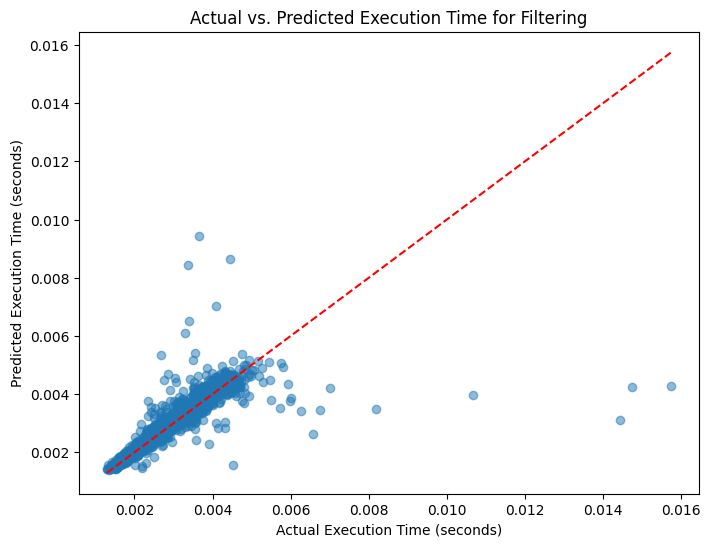

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle="--")
plt.xlabel("Actual Execution Time (seconds)")
plt.ylabel("Predicted Execution Time (seconds)")
plt.title("Actual vs. Predicted Execution Time for Filtering")
plt.show()

In [73]:
import numpy as np
import pandas as pd
import time
import random
import string
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Helper function to generate a random string of fixed length.
def random_string(length=5):
    return ''.join(random.choices(string.ascii_letters, k=length))

# Function to generate a synthetic DataFrame with a mix of int, float, and string columns.
# 'num_cols' includes the dedicated filter column ('filter_col').
def generate_mixed_df(n_rows, num_cols):
    df = pd.DataFrame()
    # Dedicated numeric column for filtering.
    #change this to be float or int
    df['filter_col'] = np.random.randint(0,1000,n_rows)
    
    # Add remaining columns with randomly chosen types.
    for i in range(num_cols - 1):
        col_type = random.choice(['int', 'float', 'string'])
        col_name = f'col_{i}'
        if col_type == 'int':
            df[col_name] = np.random.randint(0, 100, n_rows)
        elif col_type == 'float':
            df[col_name] = np.random.rand(n_rows)
        else:  # 'string'
            df[col_name] = [random_string(5) for _ in range(n_rows)]
    return df

# Function to count the number of columns by data type.
def count_dtypes(df):
    count_int = 0
    count_float = 0
    count_str = 0
    for col, dtype in df.dtypes.items():
        if pd.api.types.is_integer_dtype(dtype):
            count_int += 1
        elif pd.api.types.is_float_dtype(dtype):
            count_float += 1
        elif pd.api.types.is_object_dtype(dtype):
            count_str += 1
    return count_int, count_float, count_str

# Function to benchmark the filtering operation on 'filter_col'
def benchmark_filter(df, threshold):
    start = time.perf_counter()
    _ = df[df['filter_col'] < threshold]
    end = time.perf_counter()
    return end - start

# Benchmark experiment settings
benchmark_results = []
samples = 1000

# Generate benchmark data by varying DataFrame sizes, total columns, and thresholds.
for _ in tqdm.tqdm(range(samples)):
            n_rows = np.random.randint(100000,200000) 
            num_cols = np.random.randint(10,20) 
            thresh = np.random.randint(1,10)
            df = generate_mixed_df(n_rows, num_cols)
            elapsed_time = benchmark_filter(df, thresh)
            count_int, count_float, count_str = count_dtypes(df)
            benchmark_results.append({
                'n_rows': n_rows,
                'num_cols': num_cols,
                'threshold': thresh,
                'time': elapsed_time,
                'count_int': count_int,
                'count_float': count_float,
                'count_str': count_str
            })

# Create a DataFrame with the benchmark results.
df_results = pd.DataFrame(benchmark_results)
print(df_results)

# Prepare features and target for the regression model.
# Here we include: n_rows, num_cols, threshold, and counts of each data type.
X = df_results[['n_rows', 'num_cols', 'threshold', 'count_int', 'count_float', 'count_str']]
y = df_results['time']

# Split the data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

  0%|                   | 1/1000 [00:01<29:04,  1.75s/it]


KeyboardInterrupt: 

In [52]:
# --- Choose and Train your Model ---
print("\nTraining Model...")
model = RandomForestRegressor(n_estimators=100,
                              random_state=42,
                              n_jobs=-1,
                              max_depth=50,
                              # min_samples_split=5,
                              # min_samples_leaf=3
                             )
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate performance
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\nModel Performance (Predicting Filter Wall-Clock Time):")
print(f"Mean Absolute Error: {mae:.6f} seconds")
print(f"R² Score: {r2:.4f}")


Training Model...

Model Performance (Predicting Filter Wall-Clock Time):
Mean Absolute Error: 0.001368 seconds
R² Score: 0.9839


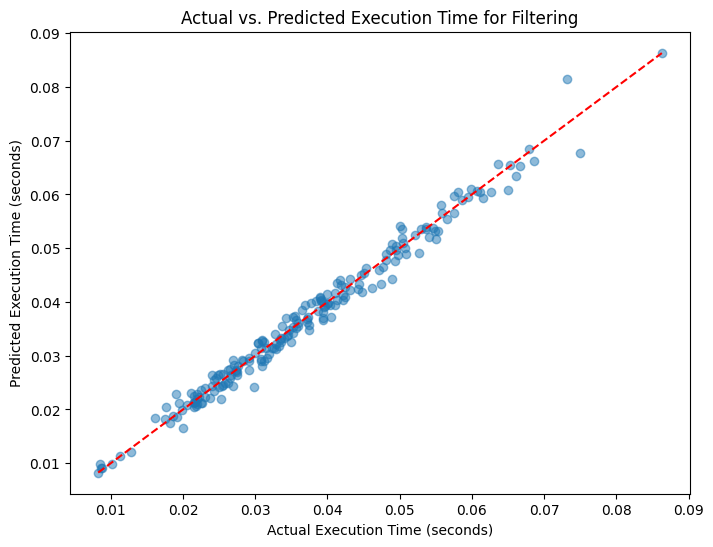

In [53]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle="--")
plt.xlabel("Actual Execution Time (seconds)")
plt.ylabel("Predicted Execution Time (seconds)")
plt.title("Actual vs. Predicted Execution Time for Filtering")
plt.show()

In [5]:
import numpy as np
import pandas as pd
import time
import random
import string
import tqdm

# Helper function to generate a random string of fixed length.
def random_string(length=5):
    return ''.join(random.choices(string.ascii_letters, k=length))

# Function to generate a synthetic DataFrame for groupby operations.
# Uses integers for the 'value' column and includes additional mixed-type columns.
def generate_groupby_df_int(n_rows, num_cols, num_groups):
    df = pd.DataFrame()
    # Create a group key column with 'num_groups' distinct groups.
    groups = [f"group_{i}" for i in range(num_groups)]
    df['group_col'] = np.random.choice(groups, n_rows)
    
    # Create an integer column for aggregation.
    df['value'] = np.random.randint(0, 100, n_rows)  # integers between 0 and 99
    
    # Add additional columns with a mix of int, float, and string types.
    # Subtracting 2 to account for the reserved columns ('group_col' and 'value').
    for i in range(num_cols - 2):
        col_type = random.choice(['int', 'float', 'string'])
        col_name = f'col_{i}'
        if col_type == 'int':
            df[col_name] = np.random.randint(0, 100, n_rows)
        elif col_type == 'float':
            df[col_name] = np.random.rand(n_rows)
        else:  # 'string'
            df[col_name] = [random_string(5) for _ in range(n_rows)]
    return df

# Function to count the number of columns by data type.
def count_dtypes(df):
    count_int, count_float, count_str = 0, 0, 0
    for col, dtype in df.dtypes.items():
        if pd.api.types.is_integer_dtype(dtype):
            count_int += 1
        elif pd.api.types.is_float_dtype(dtype):
            count_float += 1
        elif pd.api.types.is_object_dtype(dtype):
            count_str += 1
    return count_int, count_float, count_str

# Function to benchmark the groupby operation using a selected aggregation function.
def benchmark_groupby_random_agg(df, agg_type):
    start = time.time() #time.perf_counter()
    # Group by 'group_col' and perform the chosen aggregation on the 'value' column.
    _ = df.groupby('group_col').agg({'value': agg_type})
    end = time.time() #time.perf_counter()
    return end - start

# Number of random samples to generate.
samples = 1000
benchmark_results = []

# List of possible aggregation functions.
agg_options = ['mean', 'sum', 'count']

# Generate benchmark data using random values.
for _ in tqdm.tqdm(range(samples)):
    n_rows = np.random.randint(100000, 200000)      # Random number of rows between 1,000 and 10,000.
    num_cols = np.random.randint(10, 20)        # Random total number of columns between 10 and 100.
    num_groups = np.random.randint(1, 10)        # Random number of groups between 1 and 10.
    
    # Generate the synthetic DataFrame for groupby.
    df = generate_groupby_df_int(n_rows, num_cols, num_groups)
    
    # Randomly select an aggregation function.
    agg_type = random.choice(agg_options)
    
    # Benchmark the groupby operation with the selected aggregation.
    elapsed_time = benchmark_groupby_random_agg(df, agg_type)
    
    # Count the number of columns by type.
    count_int, count_float, count_str = count_dtypes(df)
    
    # Record the benchmark result along with all features.
    benchmark_results.append({
        'n_rows': n_rows,
        'num_cols': num_cols,
        'num_groups': num_groups,
        'agg_type': agg_type,    # This is the randomly selected aggregation function.
        'time': elapsed_time,
        'count_int': count_int,
        'count_float': count_float,
        'count_str': count_str
    })

# Create a DataFrame from the benchmark results.
df_results = pd.DataFrame(benchmark_results)
print(df_results)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [17:35<00:00,  1.06s/it]

     n_rows  num_cols  num_groups agg_type      time  count_int  count_float  \
0    178058        16           2      sum  0.012040          5            7   
1    117568        16           9    count  0.007444          6            6   
2    184884        18           8      sum  0.012628          8            5   
3    182266        12           7    count  0.011559          6            2   
4    126353        16           9      sum  0.009463          5            6   
..      ...       ...         ...      ...       ...        ...          ...   
995  181825        18           7      sum  0.013540          8            2   
996  139978        15           3    count  0.010294          4            4   
997  171869        14           8     mean  0.014170          5            5   
998  143955        16           4      sum  0.011514          4            6   
999  169684        18           2      sum  0.012424          7            6   

     count_str  
0            4  
1    

In [16]:
# Prepare features and target for the regression model.
# Here we include: n_rows, num_cols, threshold, and counts of each data type.
X = df_results[['n_rows', 'num_cols', 'num_groups', 'agg_type', 'count_str', 'count_float', 'count_int']]
y = df_results['time']
encoder = LabelEncoder()
# Ensure NaN ratios didn't create NaN strings before encoding

X["agg_type"] = encoder.fit_transform(X["agg_type"])
# Split the data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# --- Choose and Train your Model ---
print("\nTraining Model...")
model = RandomForestRegressor(n_estimators=150,
                              random_state=42,
                              n_jobs=-1,
                              max_depth=50,
                              # min_samples_split=5,
                              # min_samples_leaf=3
                             )
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate performance
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\nModel Performance (Predicting Filter Wall-Clock Time):")
print(f"Mean Absolute Error: {mae:.6f} seconds")
print(f"R² Score: {r2:.4f}")

/var/tmp/ipykernel_8508/3017782380.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["agg_type"] = encoder.fit_transform(X["agg_type"])



Training Model...

Model Performance (Predicting Filter Wall-Clock Time):
Mean Absolute Error: 0.000501 seconds
R² Score: 0.8984


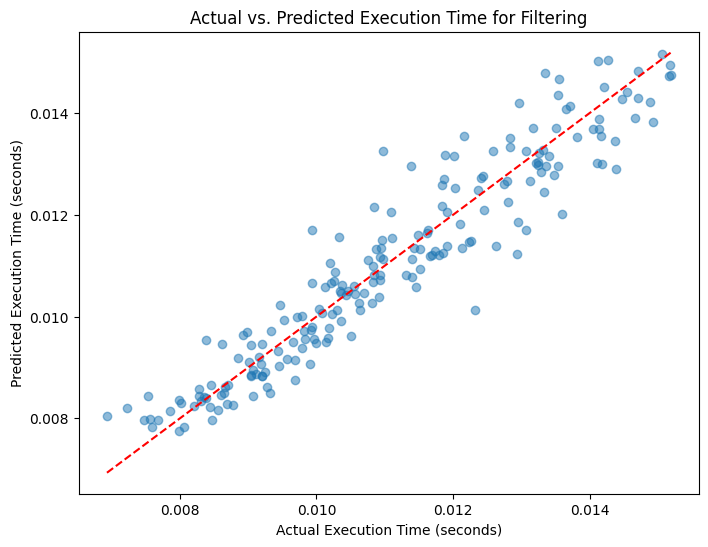

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle="--")
plt.xlabel("Actual Execution Time (seconds)")
plt.ylabel("Predicted Execution Time (seconds)")
plt.title("Actual vs. Predicted Execution Time for Filtering")
plt.show()

In [15]:
features1 = {'n_rows': 100750,
 'num_cols': 10,
 'num_groups': 69,
 'count_int': 5,
 'count_float': 1,
 'count_str': 4,
 'agg_type': 1}
x_test = pd.DataFrame([features1])
model.predict(x_test)

/opt/conda/envs/elastic/lib/python3.10/site-packages/sklearn/base.py:493: FutureWarning: The feature names should match those that were passed during fit. Starting version 1.2, an error will be raised.
Feature names must be in the same order as they were in fit.

  warnings.warn(message, FutureWarning)


array([0.00818219])

UNIQUE


In [18]:
import numpy as np
import pandas as pd
import time
import random
import string
import tqdm

# Helper function to generate a random string of fixed length.
def random_string(length=5):
    return ''.join(random.choices(string.ascii_letters, k=length))

# Function to generate a DataFrame with a dedicated 'unique_col'
# whose distinct values are controlled by the 'cardinality' parameter.
# Also adds additional columns with mixed data types.
def generate_unique_df(n_rows, num_cols, cardinality, unique_dtype='int'):
    df = pd.DataFrame()
    
    # Generate the 'unique_col' with controlled cardinality.
    if unique_dtype == 'int':
        # For integers, generate values between 0 and (cardinality - 1)
        df['unique_col'] = np.random.randint(0, cardinality, n_rows)
    elif unique_dtype == 'float':
        # For floats, generate similar integer values and cast to float.
        df['unique_col'] = np.random.randint(0, cardinality, n_rows).astype(float)
    elif unique_dtype == 'string':
        # For strings, generate a fixed pool of random strings and sample from it.
        unique_values = [random_string(5) for _ in range(cardinality)]
        df['unique_col'] = np.random.choice(unique_values, n_rows)
    else:
        raise ValueError("unique_dtype must be 'int', 'float', or 'string'")
    
    # Add additional columns with mixed data types.
    for i in range(num_cols - 1):  # subtract one for the 'unique_col'
        col_type = random.choice(['int', 'float', 'string'])
        col_name = f'col_{i}'
        if col_type == 'int':
            df[col_name] = np.random.randint(0, 100, n_rows)
        elif col_type == 'float':
            df[col_name] = np.random.rand(n_rows)
        else:  # 'string'
            df[col_name] = [random_string(5) for _ in range(n_rows)]
    return df

# Function to count the number of columns by data type in the DataFrame.
def count_dtypes(df):
    count_int, count_float, count_str = 0, 0, 0
    for col, dtype in df.dtypes.items():
        if pd.api.types.is_integer_dtype(dtype):
            count_int += 1
        elif pd.api.types.is_float_dtype(dtype):
            count_float += 1
        elif pd.api.types.is_object_dtype(dtype):
            count_str += 1
    return count_int, count_float, count_str

# Function to benchmark the unique operation on a given column.
def benchmark_unique(df, col='unique_col'):
    start = time.perf_counter()
    _ = df[col].unique()
    end = time.perf_counter()
    return end - start

# Number of random samples to generate.
samples = 5000
benchmark_results = []

# List of possible data types for the unique column.
unique_dtypes = ['int', 'float', 'string']

# Generate benchmark data using random values.
for _ in tqdm.tqdm(range(samples)):
    n_rows = np.random.randint(1000, 10000)        # Random number of rows between 1,000 and 10,000.
    num_cols = np.random.randint(10, 100)          # Random total number of columns between 10 and 100.
    # Set cardinality between 10 and n_rows to control the number of unique values.
    cardinality = np.random.randint(10, n_rows)
    # Randomly choose a data type for the unique column.
    unique_dtype = random.choice(unique_dtypes)
    
    # Generate the synthetic DataFrame.
    df = generate_unique_df(n_rows, num_cols, cardinality, unique_dtype)
    
    # Benchmark the unique operation on the 'unique_col'.
    elapsed_time = benchmark_unique(df, 'unique_col')
    
    # Count the number of columns by type.
    count_int, count_float, count_str = count_dtypes(df)
    
    # Record the benchmark result and features.
    benchmark_results.append({
        'n_rows': n_rows,
        'num_cols': num_cols,
        'cardinality': cardinality,
        'unique_dtype': unique_dtype,
        'time': elapsed_time,
        'count_int': count_int,
        'count_float': count_float,
        'count_str': count_str
    })

# Create a DataFrame from the benchmark results.
df_results = pd.DataFrame(benchmark_results)
print(df_results)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [14:20<00:00,  5.81it/s]

      n_rows  num_cols  cardinality unique_dtype      time  count_int  \
0       8735        47         5776       string  0.000784         21   
1       9616        13         4506        float  0.000376          5   
2       5742        25         4870          int  0.000256          4   
3       2242        84         1733       string  0.000320         33   
4       2536        72         1753          int  0.000259         27   
...      ...       ...          ...          ...       ...        ...   
4995    6854        74         2237          int  0.000287         28   
4996    3696        87         3431       string  0.000464         33   
4997    1314        54           52        float  0.000213         18   
4998    6773        28         1623       string  0.000585          9   
4999    4545        91         1356          int  0.000246         34   

      count_float  count_str  
0              11         15  
1               6          2  
2              11         10  

In [21]:
# Prepare features and target for the regression model.
# Here we include: n_rows, num_cols, threshold, and counts of each data type.
X = df_results[['n_rows', 'num_cols', 'cardinality', 'unique_dtype', 'count_str', 'count_float', 'count_int']]
y = df_results['time']
encoder = LabelEncoder()
# Ensure NaN ratios didn't create NaN strings before encoding

X["unique_dtype"] = encoder.fit_transform(X["unique_dtype"])
# Split the data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# --- Choose and Train your Model ---
print("\nTraining Model...")
model = RandomForestRegressor(n_estimators=150,
                              random_state=42,
                              n_jobs=-1,
                              max_depth=50,
                              # min_samples_split=5,
                              # min_samples_leaf=3
                             )
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate performance
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\nModel Performance (Predicting Filter Wall-Clock Time):")
print(f"Mean Absolute Error: {mae:.6f} seconds")
print(f"R² Score: {r2:.4f}")

/var/tmp/ipykernel_8508/2604200959.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["unique_dtype"] = encoder.fit_transform(X["unique_dtype"])



Training Model...

Model Performance (Predicting Filter Wall-Clock Time):
Mean Absolute Error: 0.000024 seconds
R² Score: 0.9615


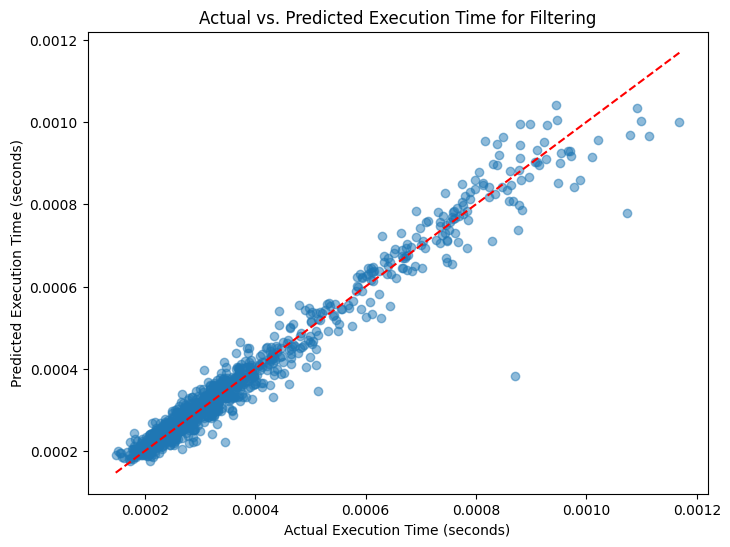

In [22]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle="--")
plt.xlabel("Actual Execution Time (seconds)")
plt.ylabel("Predicted Execution Time (seconds)")
plt.title("Actual vs. Predicted Execution Time for Filtering")
plt.show()

In [27]:
features =  {'n_rows': 7140,
        'num_cols': 34,
        'cardinality': 8,
        'unique_dtype': 2,
        'count_int': 0,
        'count_float': 15,
        'count_str': 21
            }
x_test = pd.DataFrame([features])
pred = model.predict(x_test)
print(pred*1000000)

[573.53219336]


/opt/conda/envs/elastic/lib/python3.10/site-packages/sklearn/base.py:493: FutureWarning: The feature names should match those that were passed during fit. Starting version 1.2, an error will be raised.
Feature names must be in the same order as they were in fit.

  warnings.warn(message, FutureWarning)


## drop duplicates


In [1]:
import numpy as np
import pandas as pd
import time
import random
import string
import tqdm

# Helper function to generate a random string of fixed length.
def random_string(length=5):
    return ''.join(random.choices(string.ascii_letters, k=length))

# Function to generate a DataFrame with a dedicated 'unique_col'
# whose distinct values are controlled by the 'cardinality' parameter.
# Also adds additional columns with mixed data types.
def generate_unique_df(n_rows, num_cols, cardinality, unique_dtype='int'):
    df = pd.DataFrame()
    
    # Generate the 'unique_col' with controlled cardinality.
    if unique_dtype == 'int':
        # For integers, generate values between 0 and (cardinality - 1)
        df['unique_col'] = np.random.randint(0, cardinality, n_rows)
    elif unique_dtype == 'float':
        # For floats, generate similar integer values and cast to float.
        df['unique_col'] = np.random.randint(0, cardinality, n_rows).astype(float)
    elif unique_dtype == 'string':
        # For strings, generate a fixed pool of random strings and sample from it.
        unique_values = [random_string(5) for _ in range(cardinality)]
        df['unique_col'] = np.random.choice(unique_values, n_rows)
    else:
        raise ValueError("unique_dtype must be 'int', 'float', or 'string'")
    
    # Add additional columns with mixed data types.
    for i in range(num_cols - 1):  # subtract one for the 'unique_col'
        col_type = random.choice(['int', 'float', 'string'])
        col_name = f'col_{i}'
        if col_type == 'int':
            df[col_name] = np.random.randint(0, 100, n_rows)
        elif col_type == 'float':
            df[col_name] = np.random.rand(n_rows)
        else:  # 'string'
            df[col_name] = [random_string(5) for _ in range(n_rows)]
    return df

# Function to count the number of columns by data type in the DataFrame.
def count_dtypes(df):
    count_int, count_float, count_str = 0, 0, 0
    for col, dtype in df.dtypes.items():
        if pd.api.types.is_integer_dtype(dtype):
            count_int += 1
        elif pd.api.types.is_float_dtype(dtype):
            count_float += 1
        elif pd.api.types.is_object_dtype(dtype):
            count_str += 1
    return count_int, count_float, count_str

# Function to benchmark the unique operation on a given column.
def benchmark_unique(df, col='unique_col'):
    start = time.perf_counter()
    _ = df[col].drop_duplicates()
    end = time.perf_counter()
    return end - start

# Number of random samples to generate.
samples = 5000
benchmark_results = []

# List of possible data types for the unique column.
unique_dtypes = ['int', 'float', 'string']

# Generate benchmark data using random values.
for _ in tqdm.tqdm(range(samples)):
    n_rows = np.random.randint(1000, 10000)        # Random number of rows between 1,000 and 10,000.
    num_cols = np.random.randint(10, 100)          # Random total number of columns between 10 and 100.
    # Set cardinality between 10 and n_rows to control the number of unique values.
    cardinality = np.random.randint(10, n_rows)
    # Randomly choose a data type for the unique column.
    unique_dtype = random.choice(unique_dtypes)
    
    # Generate the synthetic DataFrame.
    df = generate_unique_df(n_rows, num_cols, cardinality, unique_dtype)
    
    # Benchmark the unique operation on the 'unique_col'.
    elapsed_time = benchmark_unique(df, 'unique_col')
    
    # Count the number of columns by type.
    count_int, count_float, count_str = count_dtypes(df)
    
    # Record the benchmark result and features.
    benchmark_results.append({
        'n_rows': n_rows,
        'num_cols': num_cols,
        'cardinality': cardinality,
        'unique_dtype': unique_dtype,
        'time': elapsed_time,
        'count_int': count_int,
        'count_float': count_float,
        'count_str': count_str
    })

# Create a DataFrame from the benchmark results.
df_results = pd.DataFrame(benchmark_results)
print(df_results)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [14:47<00:00,  5.64it/s]

      n_rows  num_cols  cardinality unique_dtype      time  count_int  \
0       4576        74         1923       string  0.000671         22   
1       8707        65         7504       string  0.000915         18   
2       1659        76          238        float  0.000291         28   
3       2929        57         1960        float  0.000386         21   
4       5934        14         1136          int  0.000355          4   
...      ...       ...          ...          ...       ...        ...   
4995    8618        88         5406       string  0.001157         38   
4996    8441        17         2613       string  0.000973          3   
4997    7123        27         4994       string  0.000902         10   
4998    1938        77          783       string  0.000429         29   
4999    9412        36         8788          int  0.000546         18   

      count_float  count_str  
0              21         31  
1              23         24  
2              22         26  

In [5]:
# Prepare features and target for the regression model.
# Here we include: n_rows, num_cols, threshold, and counts of each data type.
X = df_results[['n_rows', 'num_cols', 'cardinality', 'unique_dtype', 'count_str', 'count_float', 'count_int']]
y = df_results['time']
encoder = LabelEncoder()
# Ensure NaN ratios didn't create NaN strings before encoding

X["unique_dtype"] = encoder.fit_transform(X["unique_dtype"])
# Split the data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# --- Choose and Train your Model ---
print("\nTraining Model...")
model = RandomForestRegressor(n_estimators=150,
                              random_state=42,
                              n_jobs=-1,
                              max_depth=50,
                              # min_samples_split=5,
                              # min_samples_leaf=3
                             )
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate performance
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\nModel Performance (Predicting Filter Wall-Clock Time):")
print(f"Mean Absolute Error: {mae:.6f} seconds")
print(f"R² Score: {r2:.4f}")

/var/tmp/ipykernel_46305/2604200959.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["unique_dtype"] = encoder.fit_transform(X["unique_dtype"])



Training Model...

Model Performance (Predicting Filter Wall-Clock Time):
Mean Absolute Error: 0.000035 seconds
R² Score: 0.9288


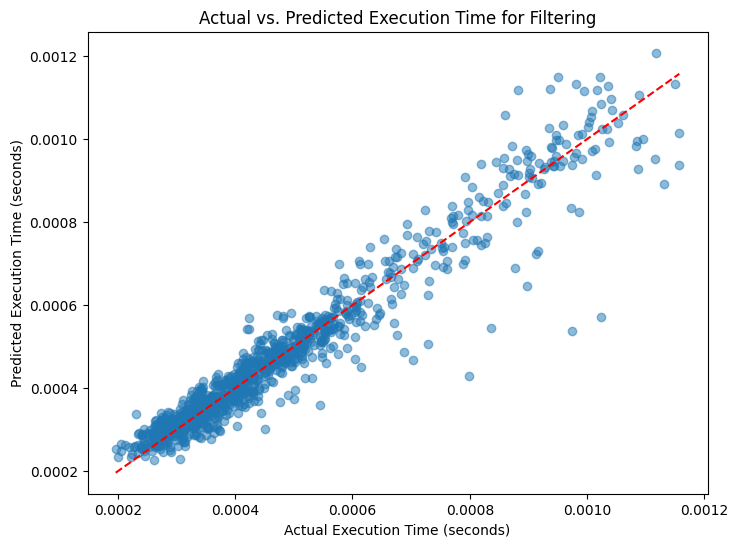

In [6]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle="--")
plt.xlabel("Actual Execution Time (seconds)")
plt.ylabel("Predicted Execution Time (seconds)")
plt.title("Actual vs. Predicted Execution Time for Filtering")
plt.show()

In [7]:
features =  {'n_rows': 7140,
        'num_cols': 34,
        'cardinality': 8,
        'unique_dtype': 2,
        'count_int': 0,
        'count_float': 15,
        'count_str': 21
            }
x_test = pd.DataFrame([features])
pred = model.predict(x_test)
print(pred*1000000)

[692.04667998]


/opt/conda/envs/elastic/lib/python3.10/site-packages/sklearn/base.py:493: FutureWarning: The feature names should match those that were passed during fit. Starting version 1.2, an error will be raised.
Feature names must be in the same order as they were in fit.

  warnings.warn(message, FutureWarning)


##GPU


In [2]:
import numpy as np
import cudf
import time
import random
import string
import tqdm
import pandas as pd  # For final DataFrame conversion and display

# Helper function to generate a random string of fixed length.
def random_string(length=5):
    return ''.join(random.choices(string.ascii_letters, k=length))

# Function to generate a cuDF DataFrame with a dedicated 'unique_col'
# whose distinct values are controlled by the 'cardinality' parameter.
# Also adds additional columns with mixed data types.
def generate_unique_df(n_rows, num_cols, cardinality, unique_dtype='int'):
    data = {}
    
    # Generate the 'unique_col' with controlled cardinality.
    if unique_dtype == 'int':
        # For integers, generate values between 0 and (cardinality - 1)
        data['unique_col'] = np.random.randint(0, cardinality, n_rows)
    elif unique_dtype == 'float':
        # For floats, generate similar integer values and cast to float.
        data['unique_col'] = np.random.randint(0, cardinality, n_rows).astype(float)
    elif unique_dtype == 'string':
        # For strings, generate a fixed pool of random strings and sample from it.
        unique_values = [random_string(5) for _ in range(cardinality)]
        data['unique_col'] = np.random.choice(unique_values, n_rows)
    else:
        raise ValueError("unique_dtype must be 'int', 'float', or 'string'")
    
    # Add additional columns with mixed data types.
    for i in range(num_cols - 1):  # subtract one for the 'unique_col'
        col_type = random.choice(['int', 'float', 'string'])
        col_name = f'col_{i}'
        if col_type == 'int':
            data[col_name] = np.random.randint(0, 100, n_rows)
        elif col_type == 'float':
            data[col_name] = np.random.rand(n_rows)
        else:  # 'string'
            data[col_name] = [random_string(5) for _ in range(n_rows)]
            
    # Create a cuDF DataFrame from the generated dictionary.
    df = cudf.DataFrame(data)
    return df

# Function to count the number of columns by data type in a cuDF DataFrame.
def count_dtypes(df):
    count_int, count_float, count_str = 0, 0, 0
    for col, dtype in df.dtypes.items():
        if np.issubdtype(dtype, np.integer):
            count_int += 1
        elif np.issubdtype(dtype, np.floating):
            count_float += 1
        elif dtype == 'object' or dtype.name == 'object':
            count_str += 1
    return count_int, count_float, count_str

# Function to benchmark the unique operation on a given column using cuDF.
def benchmark_unique(df, col='unique_col'):
    start = time.perf_counter()
    _ = df[col].drop_duplicates()  # cuDF's equivalent of unique()
    end = time.perf_counter()
    return end - start

# Number of random samples to generate.
samples = 5000
benchmark_results = []

# List of possible data types for the unique column.
unique_dtypes = ['int', 'float', 'string']

# Generate benchmark data using random values.
for _ in tqdm.tqdm(range(samples)):
    n_rows = np.random.randint(1000, 10000)        # Random number of rows between 1,000 and 10,000.
    num_cols = np.random.randint(10, 100)          # Random total number of columns between 10 and 100.
    # Set cardinality between 10 and n_rows to control the number of unique values.
    cardinality = np.random.randint(10, n_rows)
    # Randomly choose a data type for the unique column.
    unique_dtype = random.choice(unique_dtypes)
    
    # Generate the synthetic cuDF DataFrame.
    df = generate_unique_df(n_rows, num_cols, cardinality, unique_dtype)
    
    # Benchmark the unique operation on the 'unique_col'.
    elapsed_time = benchmark_unique(df, 'unique_col')
    
    # Count the number of columns by type.
    count_int, count_float, count_str = count_dtypes(df)
    
    # Record the benchmark result and features.
    benchmark_results.append({
        'n_rows': n_rows,
        'num_cols': num_cols,
        'cardinality': cardinality,
        'unique_dtype': unique_dtype,
        'time': elapsed_time,
        'count_int': count_int,
        'count_float': count_float,
        'count_str': count_str
    })

# Convert the results to a pandas DataFrame for easy inspection.
df_results = pd.DataFrame(benchmark_results)
print(df_results)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [15:32<00:00,  5.36it/s]

      n_rows  num_cols  cardinality unique_dtype      time  count_int  \
0       5625        24         5503          int  0.001363          7   
1       6352        91         4471          int  0.001396         36   
2       9310        17         7085        float  0.001374          7   
3       9244        73         6506          int  0.001289         28   
4       5094        48         3080       string  0.001447         16   
...      ...       ...          ...          ...       ...        ...   
4995    1661        53         1306       string  0.001501         20   
4996    1737        41          625       string  0.001355         13   
4997    2136        30          259       string  0.001390          9   
4998    5983        56         1885       string  0.001548         21   
4999    3978        80         3622       string  0.001515         25   

      count_float  count_str  
0               9          8  
1              27         28  
2               4          6  

In [7]:
# Prepare features and target for the regression model.
# Here we include: n_rows, num_cols, threshold, and counts of each data type.
X = df_results[['n_rows', 'num_cols', 'cardinality', 'unique_dtype', 'count_str', 'count_float', 'count_int']]
y = df_results['time']
encoder = LabelEncoder()
# Ensure NaN ratios didn't create NaN strings before encoding

X["unique_dtype"] = encoder.fit_transform(X["unique_dtype"])
# Split the data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# --- Choose and Train your Model ---
print("\nTraining Model...")
model = RandomForestRegressor(n_estimators=200,
                              random_state=42,
                              n_jobs=-1,
                              max_depth=50,
                              # min_samples_split=5,
                              # min_samples_leaf=3
                             )
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate performance
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\nModel Performance (Predicting Filter Wall-Clock Time):")
print(f"Mean Absolute Error: {mae:.6f} seconds")
print(f"R² Score: {r2:.4f}")

/var/tmp/ipykernel_36642/3270868597.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["unique_dtype"] = encoder.fit_transform(X["unique_dtype"])



Training Model...

Model Performance (Predicting Filter Wall-Clock Time):
Mean Absolute Error: 0.000066 seconds
R² Score: 0.5561


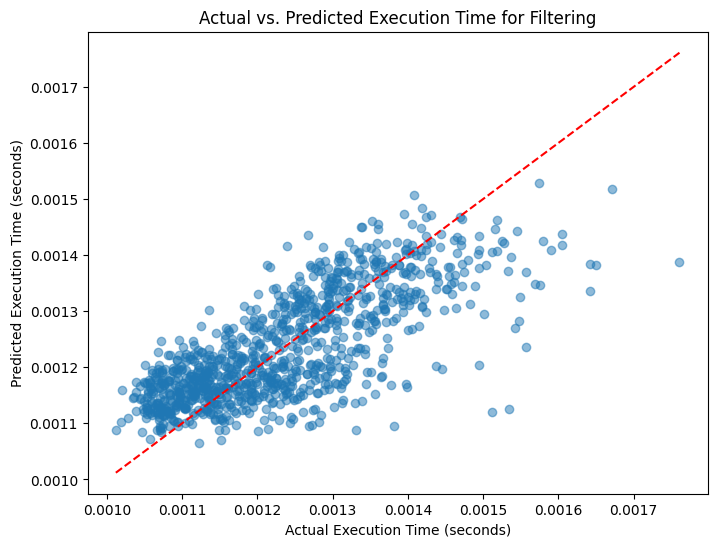

In [6]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle="--")
plt.xlabel("Actual Execution Time (seconds)")
plt.ylabel("Predicted Execution Time (seconds)")
plt.title("Actual vs. Predicted Execution Time for Filtering")
plt.show()

In [14]:
import numpy as np
import cudf
import time
import random
import string
import tqdm
import pandas as pd  # For final DataFrame conversion and display

# Helper function to generate a random string of fixed length.
def random_string(length=5):
    return ''.join(random.choices(string.ascii_letters, k=length))

# Function to generate a cuDF DataFrame with a dedicated 'unique_col'
# whose distinct values are controlled by the 'cardinality' parameter.
# Also adds additional columns with mixed data types.
def generate_unique_df(n_rows, num_cols, cardinality, unique_dtype='int'):
    data = {}
    
    # Generate the 'unique_col' with controlled cardinality.
    if unique_dtype == 'int':
        # For integers, generate values between 0 and (cardinality - 1)
        data['unique_col'] = np.random.randint(0, cardinality, n_rows)
    elif unique_dtype == 'float':
        # For floats, generate similar integer values and cast to float.
        data['unique_col'] = np.random.randint(0, cardinality, n_rows).astype(float)
    elif unique_dtype == 'string':
        # For strings, generate a fixed pool of random strings and sample from it.
        unique_values = [random_string(5) for _ in range(cardinality)]
        data['unique_col'] = np.random.choice(unique_values, n_rows)
    else:
        raise ValueError("unique_dtype must be 'int', 'float', or 'string'")
    
    # Add additional columns with mixed data types.
    for i in range(num_cols - 1):  # subtract one for the 'unique_col'
        col_type = random.choice(['int', 'float', 'string'])
        col_name = f'col_{i}'
        if col_type == 'int':
            data[col_name] = np.random.randint(0, 100, n_rows)
        elif col_type == 'float':
            data[col_name] = np.random.rand(n_rows)
        else:  # 'string'
            data[col_name] = ['aaaaa' for _ in range(n_rows)]
            
    # Create a cuDF DataFrame from the generated dictionary.
    df = cudf.DataFrame(data)
    return df

# Function to count the number of columns by data type in a cuDF DataFrame.
def count_dtypes(df):
    count_int, count_float, count_str = 0, 0, 0
    for col, dtype in df.dtypes.items():
        if np.issubdtype(dtype, np.integer):
            count_int += 1
        elif np.issubdtype(dtype, np.floating):
            count_float += 1
        elif dtype == 'object' or dtype.name == 'object':
            count_str += 1
    return count_int, count_float, count_str

# Function to benchmark the unique operation on a given column using cuDF.
def benchmark_unique(df, col='unique_col'):
    start = time.perf_counter()
    _ = df[col].drop_duplicates()  # cuDF's equivalent of unique()
    end = time.perf_counter()
    return end - start

# Number of random samples to generate.
samples = 5000
benchmark_results = []

# List of possible data types for the unique column.
unique_dtypes = ['int', 'float', 'string']

# Generate benchmark data using random values.
for _ in tqdm.tqdm(range(samples)):
    n_rows = np.random.randint(10000, 100000)        # Random number of rows between 1,000 and 10,000.
    num_cols = np.random.randint(10, 100)          # Random total number of columns between 10 and 100.
    # Set cardinality between 10 and n_rows to control the number of unique values.
    cardinality = np.random.randint(10, n_rows)
    # Randomly choose a data type for the unique column.
    unique_dtype = random.choice(unique_dtypes)
    
    # Generate the synthetic cuDF DataFrame.
    df = generate_unique_df(n_rows, num_cols, cardinality, unique_dtype)
    
    # Benchmark the unique operation on the 'unique_col'.
    elapsed_time = benchmark_unique(df, 'unique_col')
    
    # Count the number of columns by type.
    count_int, count_float, count_str = count_dtypes(df)
    
    # Record the benchmark result and features.
    benchmark_results.append({
        'n_rows': n_rows,
        'num_cols': num_cols,
        'cardinality': cardinality,
        'unique_dtype': unique_dtype,
        'time': elapsed_time,
        'count_int': count_int,
        'count_float': count_float,
        'count_str': count_str
    })

# Convert the results to a pandas DataFrame for easy inspection.
df_results = pd.DataFrame(benchmark_results)
print(df_results)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [14:02<00:00,  5.93it/s]

      n_rows  num_cols  cardinality unique_dtype      time  count_int  \
0      97997        91        61963          int  0.001975         31   
1      21117        48        20530       string  0.001721         16   
2      84292        28         1500        float  0.001591         12   
3      67108        59        51404        float  0.001356         24   
4      18938        29         6056          int  0.001417         12   
...      ...       ...          ...          ...       ...        ...   
4995   67103        98        21062        float  0.001319         35   
4996   65574        32        33436       string  0.001455         10   
4997   47443        83         6724          int  0.001388         39   
4998   98900        61         2262          int  0.001327         22   
4999   76592        90        21829          int  0.001340         24   

      count_float  count_str  
0              26         34  
1              17         15  
2               7          9  

In [20]:
# Prepare features and target for the regression model.
# Here we include: n_rows, num_cols, threshold, and counts of each data type.
X = df_results[['n_rows', 'num_cols', 'cardinality', 'unique_dtype', 'count_float', 'count_int','count_str']]
y = df_results['time']
encoder = LabelEncoder()
# Ensure NaN ratios didn't create NaN strings before encoding

X["unique_dtype"] = encoder.fit_transform(X["unique_dtype"])
# Split the data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# --- Choose and Train your Model ---
print("\nTraining Model...")
model = RandomForestRegressor(n_estimators=200,
                              random_state=42,
                              n_jobs=-1,
                              max_depth=50,
                              # min_samples_split=5,
                              # min_samples_leaf=3
                             )
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate performance
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\nModel Performance (Predicting Filter Wall-Clock Time):")
print(f"Mean Absolute Error: {mae:.6f} seconds")
print(f"R² Score: {r2:.4f}")

/var/tmp/ipykernel_104946/4247906836.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["unique_dtype"] = encoder.fit_transform(X["unique_dtype"])



Training Model...

Model Performance (Predicting Filter Wall-Clock Time):
Mean Absolute Error: 0.000086 seconds
R² Score: 0.4918


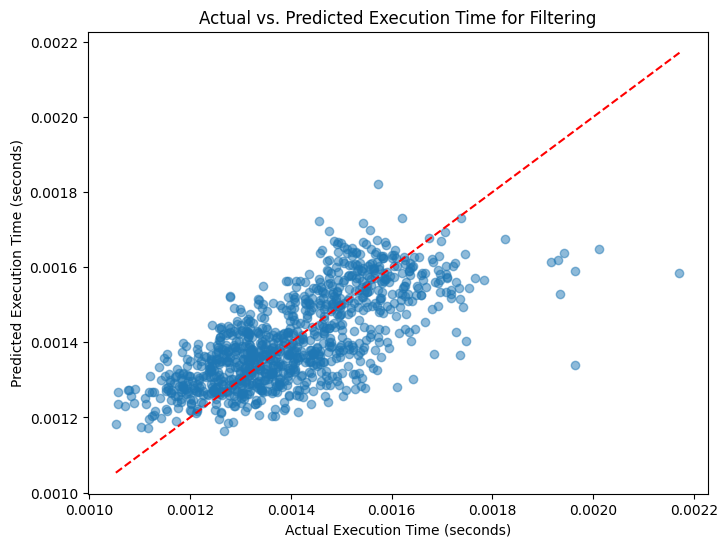

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle="--")
plt.xlabel("Actual Execution Time (seconds)")
plt.ylabel("Predicted Execution Time (seconds)")
plt.title("Actual vs. Predicted Execution Time for Filtering")

plt.show()

In [6]:
import numpy as np
import cudf
import cupy as cp  # Import cupy for potential GPU-side generation
import time
import random
import string
import tqdm
import pandas as pd

# --- Constants ---
# Create a reasonably large pool of unique strings to sample from for non-unique columns.
# This avoids generating millions of tiny Python strings individually.
STRING_POOL_SIZE = 1000
STRING_LENGTH = 5
# Generate the pool once using the original helper function
_string_pool = [
    ''.join(random.choices(string.ascii_letters, k=STRING_LENGTH))
    for _ in range(STRING_POOL_SIZE)
]
# Convert pool to NumPy array for faster indexing/choice
_string_pool_np = np.array(_string_pool, dtype=object)


# --- Helper Functions ---
# Optimized helper function to generate a random string (only used for the unique string pool)
def random_string(length=5):
    # This is still needed for the unique column's pool if cardinality is high
    return ''.join(random.choices(string.ascii_letters, k=length))

# Optimized function to generate a cuDF DataFrame
def generate_unique_df_optimized(n_rows, num_cols, cardinality, unique_dtype='int'):
    data = {}

    # Generate the 'unique_col' with controlled cardinality using NumPy (CPU).
    # Transferring numpy arrays to cudf is generally efficient.
    if unique_dtype == 'int':
        # Use NumPy for generation on CPU
        data['unique_col'] = np.random.randint(0, cardinality, n_rows, dtype=np.int64)
    elif unique_dtype == 'float':
        # Use NumPy for generation on CPU
        data['unique_col'] = np.random.randint(0, cardinality, n_rows).astype(np.float64)
    elif unique_dtype == 'string':
        # Generate a specific pool for the unique values (CPU)
        unique_values = [random_string(STRING_LENGTH) for _ in range(cardinality)]
        # Sample from this pool using NumPy (CPU)
        data['unique_col'] = np.random.choice(unique_values, n_rows)
    else:
        raise ValueError("unique_dtype must be 'int', 'float', or 'string'")

    # Add additional columns with mixed data types using NumPy vectorized operations.
    for i in range(num_cols - 1):  # subtract one for the 'unique_col'
        col_type = random.choice(['int', 'float', 'string'])
        col_name = f'col_{i}'
        if col_type == 'int':
            data[col_name] = np.random.randint(0, 100, n_rows, dtype=np.int64)
        elif col_type == 'float':
            data[col_name] = np.random.rand(n_rows).astype(np.float64)
        else:  # 'string'
            # *** OPTIMIZATION: Sample from the pre-defined string pool using numpy ***
            data[col_name] = np.random.choice(_string_pool_np, n_rows)

    # Create a cuDF DataFrame from the dictionary of NumPy arrays.
    # cuDF handles the efficient transfer from host (NumPy) to device (GPU).
    df = cudf.DataFrame(data)
    return df

# --- Original Function (for comparison, if needed) ---
# (Keep your original `generate_unique_df` function here if you want to compare timings)
def generate_unique_df_original(n_rows, num_cols, cardinality, unique_dtype='int'):
    data = {}
    if unique_dtype == 'int':
        data['unique_col'] = np.random.randint(0, cardinality, n_rows)
    elif unique_dtype == 'float':
        data['unique_col'] = np.random.randint(0, cardinality, n_rows).astype(float)
    elif unique_dtype == 'string':
        unique_values = [random_string(5) for _ in range(cardinality)]
        data['unique_col'] = np.random.choice(unique_values, n_rows)
    else:
        raise ValueError("unique_dtype must be 'int', 'float', or 'string'")

    for i in range(num_cols - 1):
        col_type = random.choice(['int', 'float', 'string'])
        col_name = f'col_{i}'
        if col_type == 'int':
            data[col_name] = np.random.randint(0, 100, n_rows)
        elif col_type == 'float':
            data[col_name] = np.random.rand(n_rows)
        else: # 'string'
             # *** SLOW PART ***
            data[col_name] = [random_string(5) for _ in range(n_rows)]

    df = cudf.DataFrame(data)
    return df

# --- Benchmarking Functions ---
# Function to count the number of columns by data type in a cuDF DataFrame.
def count_dtypes(df):
    count_int, count_float, count_str = 0, 0, 0
    # Use df.dtypes which returns a pandas Series
    dtypes_series = df.dtypes
    for dtype in dtypes_series:
        # Check using pandas/numpy dtype properties
        if pd.api.types.is_integer_dtype(dtype):
             count_int += 1
        elif pd.api.types.is_float_dtype(dtype):
             count_float += 1
        elif pd.api.types.is_string_dtype(dtype) or pd.api.types.is_object_dtype(dtype):
             count_str += 1
        # Add other types if necessary, e.g., boolean, datetime
    return count_int, count_float, count_str

# Function to benchmark the unique operation on a given column using cuDF.
def benchmark_unique(df, col='unique_col'):
    # Ensure computation is finished before stopping timer using synchronize()
    cp.cuda.runtime.deviceSynchronize()
    start = time.perf_counter()
    _ = df[col].drop_duplicates()
    cp.cuda.runtime.deviceSynchronize() # Ensure unique() is finished
    end = time.perf_counter()
    return end - start

# --- Main Loop ---
samples = 2000 # Reduced samples for quicker testing, increase back if needed
benchmark_results = []

# List of possible data types for the unique column.
unique_dtypes = ['int', 'float', 'string']

# Generate benchmark data using random values.
print("Starting benchmark...")
for i in tqdm.tqdm(range(samples)):
    n_rows = np.random.randint(1000, 100000)
    num_cols = np.random.randint(10, 100)
    # Ensure cardinality is reasonable (at least 2, max n_rows)
    cardinality = np.random.randint(10, max(11, n_rows)) # Ensure cardinality <= n_rows
    unique_dtype = random.choice(unique_dtypes)

    # --- Generate DataFrame using OPTIMIZED function ---
    # gen_start = time.perf_counter()
    # Use the optimized function
    df = generate_unique_df_optimized(n_rows, num_cols, cardinality, unique_dtype)
    # gen_end = time.perf_counter()
    # gen_time = gen_end - gen_start
    # ---

    # Benchmark the unique operation
    unique_time = benchmark_unique(df, 'unique_col')

    # Count dtypes
    count_int, count_float, count_str = count_dtypes(df)

    # Record results
    benchmark_results.append({
        'n_rows': n_rows,
        'num_cols': num_cols,
        'cardinality': cardinality,
        'unique_dtype': unique_dtype,
        'unique_time': unique_time, # Rename 'time' for clarity
        'count_int': count_int,
        'count_float': count_float,
        'count_str': count_str
    })

    # Optional: Clear GPU memory if running many large iterations
    # (May add overhead, use if memory errors occur)
    del df
    cp.get_default_memory_pool().free_all_blocks()


# --- Display Results ---
print("\nBenchmark finished. Results:")
df_results = pd.DataFrame(benchmark_results)
# Display relevant columns, potentially aggregate or sort
# print(df_results[['n_rows', 'num_cols', 'cardinality', 'unique_dtype', 'gen_time', 'unique_time']].head())
# print("\nGeneration Time Stats:")
# print(df_results['gen_time'].describe())
# print("\nUnique Time Stats:")
# print(df_results['unique_time'].describe())

Starting benchmark...


 35%|████████████████████████████████████████▌                                                                            | 694/2000 [02:10<04:06,  5.30it/s]


KeyboardInterrupt: 

In [4]:
# Import necessary libraries at the top if not already done
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import pandas as pd # Ensure pandas is imported
from xgboost import XGBRegressor
# --- (Keep your data generation and benchmarking code as is) ---

# --- Display Results ---
print("\nBenchmark finished. Results:")
df_results = pd.DataFrame(benchmark_results)
print(df_results.head()) # Good to check the raw results

# Prepare features and target
X = df_results[['n_rows', 'num_cols', 'cardinality', 'unique_dtype', 'count_str', 'count_float', 'count_int']]
y = df_results['unique_time']


encoder = LabelEncoder()
X["unique_dtype"] = encoder.fit_transform(X["unique_dtype"])
# --- Corrected Preprocessing ---
# 1. Split Data FIRST
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialize Encoder
encoder = LabelEncoder()







# --- Choose and Train your Model ---
print("\nTraining Model...")
# Consider adjusting hyperparameters if the fix doesn't fully resolve the issue
model = XGBRegressor(n_estimators=200,
                              random_state=42,
                              n_jobs=-1,
                              max_depth=50, # Maybe start simpler (e.g., 10-20)
                              # min_samples_split=5, # Consider uncommenting/adjusting
                              # min_samples_leaf=3   # Consider uncommenting/adjusting
                             )
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)



# Evaluate performance
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\nModel Performance (Predicting Unique Wall-Clock Time):") # Renamed target
print(f"Mean Absolute Error: {mae:.6f} seconds")
print(f"R² Score: {r2:.4f}")

# Optional: Analyze Feature Importances
print("\nFeature Importances:")
importances = pd.DataFrame({'feature': X_train.columns, 'importance': model.feature_importances_})
print(importances.sort_values('importance', ascending=False))


Benchmark finished. Results:
   n_rows  num_cols  cardinality unique_dtype  unique_time  count_int  \
0   44189        77        40820        float     0.011729         21   
1   68948        26        41119          int     0.000969          8   
2   73053        60        23182        float     0.000993         24   
3   14888        11        13031       string     0.001176          5   
4   82167        93        37064        float     0.001084         23   

   count_float  count_str  
0           33         23  
1            7         11  
2           18         18  
3            3          3  
4           38         32  

Training Model...

Model Performance (Predicting Unique Wall-Clock Time):
Mean Absolute Error: 0.000279 seconds
R² Score: -0.0003

Feature Importances:
        feature  importance
4     count_str    0.316450
0        n_rows    0.226088
1      num_cols    0.144068
5   count_float    0.128546
6     count_int    0.095529
2   cardinality    0.061958
3  unique_dtyp

/var/tmp/ipykernel_104946/1204279336.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["unique_dtype"] = encoder.fit_transform(X["unique_dtype"])


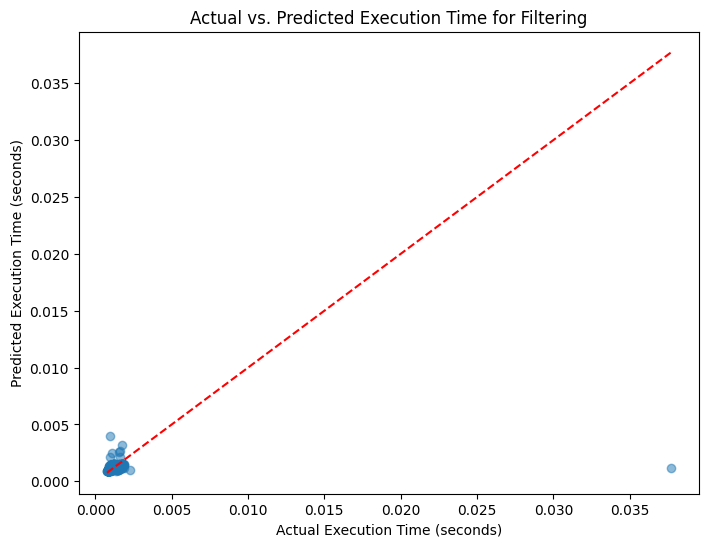

In [5]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle="--")
plt.xlabel("Actual Execution Time (seconds)")
plt.ylabel("Predicted Execution Time (seconds)")
plt.title("Actual vs. Predicted Execution Time for Filtering")
plt.show()

In [32]:
X_train, y_train

(     n_rows  num_cols  cardinality  unique_dtype  count_str  count_float  \
 29   185190        55        22158             0         12           23   
 535  167602        29       107559             1         12            9   
 695  119168        73        54600             1         26           20   
 557  190359        57       131567             2         19           25   
 836  125780        31        75702             0          8           10   
 ..      ...       ...          ...           ...        ...          ...   
 106  102274        95        84174             2         34           31   
 270  167210        57       105371             0         21           16   
 860  105898        77        82331             0         26           20   
 435  117792        65        79844             1         28           22   
 102  199678        94        81461             2         29           26   
 
      count_int  
 29          20  
 535          8  
 695         27  
 5

<AxesSubplot: >

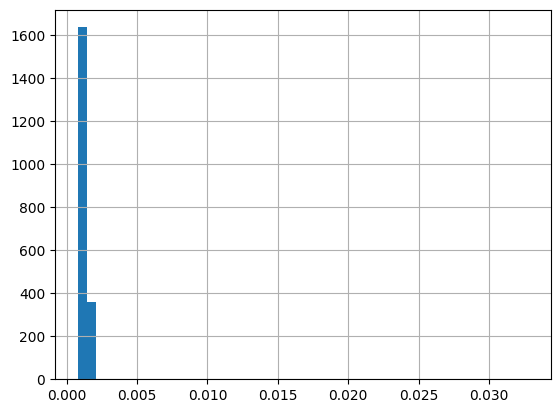

In [58]:
df_results['unique_time'].hist(bins=50)

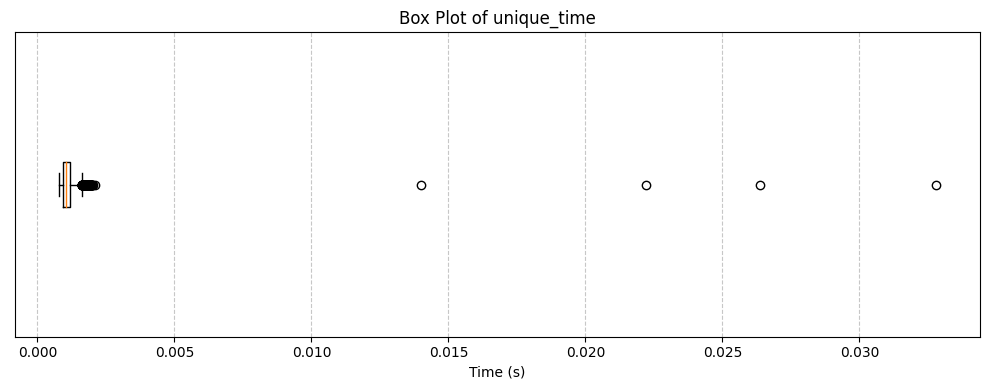

In [56]:
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 4))
    plt.boxplot(df_results['unique_time'], vert=False, showfliers=True) # Show outliers explicitly
    plt.title('Box Plot of unique_time')
    plt.xlabel('Time (s)')
    plt.yticks([]) # Hide y-axis ticks as it's just one variable
    plt.grid(True, axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib not installed. Skipping box plot plotting.")